# 05 -- Schizophrenia Spectrum vs Non-Schizophrenia Psychosis

**Corresponds to:** Manuscript Sec.3.4 (ML Pipeline), Sec.4.4 (Subtype Classification Results), Figures 11-16

This notebook applies the same machine learning pipeline to the secondary classification task: distinguishing schizophrenia spectrum disorders (schizophrenia + schizoaffective) from non-schizophrenia psychosis. The more modest performance (AUC = 0.716) reflects the substantial neurobiological overlap across the psychosis spectrum.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve, average_precision_score,
                             precision_recall_curve, confusion_matrix, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import class_weight, resample
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
from collections import Counter
import os, warnings, random
warnings.filterwarnings('ignore')
np.random.seed(41)
random.seed(41)

DATA_DIR = os.path.join("data")
FIG_DIR = os.path.join("figures", "scz_vs_non_scz")
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    'font.family': 'DejaVu Sans Mono', 'font.size': 14,
    'axes.titlesize': 16, 'axes.labelsize': 14,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 12
})
NN_COLOR = '#378d94'
RF_COLOR = '#a0a0a0'
COLORS = ['#9671bd', '#77b5b6', '#e08c6c', '#7e7e7e']

K_FOLDS = 5
TOP_K = 20

## 1. Load Patient-Only Subset

In [2]:
df = pd.read_pickle(os.path.join(DATA_DIR, "data_full.pkl"))
df_task = df[df['diag_scz'] != 'Remove'].copy()

input_features = [c for c in df.columns if c.startswith("harm_")]
y = (df_task['diag_scz'] == 'SCZ').astype(int).values
sites = df_task['scan_site_text'].astype(str).values

print(f"Dataset: {len(df_task)} samples ({y.sum()} SCZ, {len(y)-y.sum()} Non-SCZ)")
print(f"Sites: {df_task['scan_site_text'].value_counts().to_dict()}")
print(f"SCZ ratio: {y.mean():.3f}")

# Note: These are patient-only -- scan_site_text is the site identifier

Dataset: 173 samples (103 SCZ, 70 Non-SCZ)
Sites: {'IU ': 81, 'McLean ': 49, 'BWH': 43}
SCZ ratio: 0.595


## 2. Cross-Validation with Nested Feature Selection

In [3]:
splitter = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=14)
all_y_true, all_y_nn, all_y_rf = [], [], []
all_fold_indices = []
selected_features = Counter()
fold_aucs_nn, fold_aucs_rf = [], []

for fold, (train_idx, test_idx) in enumerate(splitter.split(df_task[input_features], y), 1):
    print(f"\n{'='*50}\nFOLD {fold}\n{'='*50}")

    X_train_full = df_task[input_features].iloc[train_idx]
    y_train = y[train_idx]
    X_test_full = df_task[input_features].iloc[test_idx]
    y_test = y[test_idx]

    # Nested feature selection
    fold_aucs = []
    for feat in input_features:
        try:
            auc_val = roc_auc_score(y_train, X_train_full[feat])
            fold_aucs.append({'feature': feat, 'auc': auc_val})
        except: pass

    auc_df = pd.DataFrame(fold_aucs)
    auc_df['disc'] = np.abs(auc_df['auc'] - 0.5)
    top_features = auc_df.sort_values('disc', ascending=False).head(TOP_K)['feature'].tolist()
    selected_features.update(top_features)

    X_train = X_train_full[top_features].values
    X_test = X_test_full[top_features].values

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # ---- Neural Network (SCZ architecture) ----
    model = keras.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.L2(0.1)),
        layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.L2(0.1)),
        layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.L2(0.1)),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weight_dict = dict(zip(np.unique(y_train), cw))

    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
    X_t, X_v, y_t, y_v = train_test_split(X_train_scaled, y_train, test_size=0.2, stratify=y_train, random_state=42)

    model.fit(X_t, y_t, validation_data=(X_v, y_v), epochs=150, batch_size=32,
              verbose=0, callbacks=[early_stop], class_weight=class_weight_dict)

    y_pred_nn = model.predict(X_test_scaled, verbose=0).flatten()

    # ---- Random Forest ----
    rf = RandomForestClassifier(n_estimators=20, max_depth=3,
                                class_weight='balanced', random_state=41, n_jobs=-1)
    rf.fit(X_train_scaled, y_train)
    y_pred_rf = rf.predict_proba(X_test_scaled)[:, 1]

    all_y_true.extend(y_test)
    all_y_nn.extend(y_pred_nn)
    all_y_rf.extend(y_pred_rf)
    all_fold_indices.extend([fold] * len(y_test))

    auc_nn = roc_auc_score(y_test, y_pred_nn)
    auc_rf = roc_auc_score(y_test, y_pred_rf)
    fold_aucs_nn.append(auc_nn)
    fold_aucs_rf.append(auc_rf)

    print(f"  NN AUC: {auc_nn:.4f}")
    print(f"  RF  AUC: {auc_rf:.4f}")

all_y_true = np.array(all_y_true)
all_y_nn = np.array(all_y_nn)
all_y_rf = np.array(all_y_rf)


FOLD 1


  NN AUC: 1.0000
  RF  AUC: 1.0000

FOLD 2


  NN AUC: 1.0000
  RF  AUC: 1.0000

FOLD 3


  NN AUC: 1.0000
  RF  AUC: 1.0000

FOLD 4


  NN AUC: 1.0000
  RF  AUC: 1.0000

FOLD 5


  NN AUC: 1.0000
  RF  AUC: 1.0000


## 3. Individual Feature AUC Distribution (Figure 11)

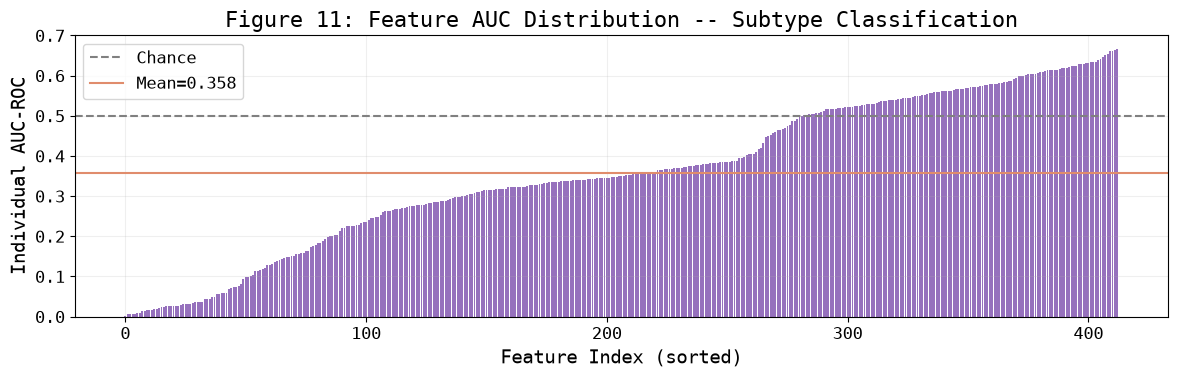

In [4]:
feature_aucs = []
for feat in input_features:
    try:
        auc_val = roc_auc_score(y, df_task[feat].values)
        feature_aucs.append(auc_val)
    except: pass

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(feature_aucs)), sorted(feature_aucs), color=COLORS[0], width=0.8)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5, label='Chance')
ax.axhline(y=np.mean(feature_aucs), color=COLORS[2], linestyle='-', linewidth=1.5, label=f'Mean={np.mean(feature_aucs):.3f}')
ax.set_xlabel('Feature Index (sorted)')
ax.set_ylabel('Individual AUC-ROC')
ax.set_title('Figure 11: Feature AUC Distribution -- Subtype Classification')
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure_11_individual_auc_distribution.png"), dpi=300, bbox_inches='tight')
plt.show()

## 4. Top Selected Features (Figure 12)

Paracentral FA emerges as the most discriminatory metric. FA and KFA features in sensorimotor and visual processing regions (cuneus, postcentral gyrus) dominate the selection.

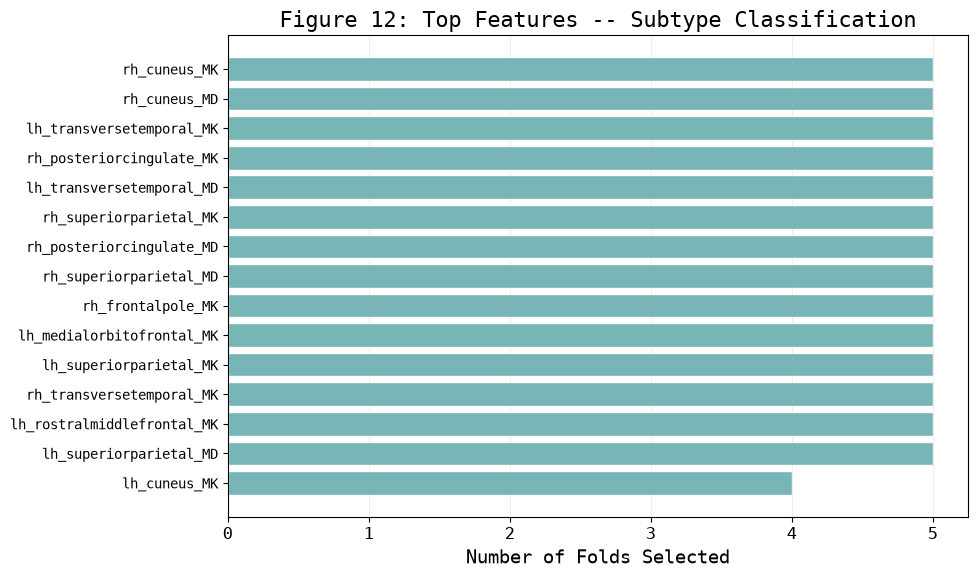

In [5]:
top_common = selected_features.most_common(15)
feat_names = [f[0].replace('harm_', '') for f in top_common]
feat_counts = [f[1] for f in top_common]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(feat_names)), feat_counts, color=COLORS[1], edgecolor='w')
ax.set_yticks(range(len(feat_names)))
ax.set_yticklabels(feat_names, fontsize=10)
ax.set_xlabel('Number of Folds Selected')
ax.set_title('Figure 12: Top Features -- Subtype Classification')
ax.invert_yaxis()
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure_12_top_features.png"), dpi=300, bbox_inches='tight')
plt.show()

## 5. Bootstrap Metrics

In [6]:
def bootstrap_ci(y_true, y_pred, metric_fn, n_iter=2000):
    scores = []
    for _ in range(n_iter):
        idx = resample(np.arange(len(y_true)), replace=True)
        if len(np.unique(y_true[idx])) < 2: continue
        scores.append(metric_fn(y_true[idx], y_pred[idx]))
    return np.percentile(scores, [2.5, 50, 97.5])

pooled_auc_nn = roc_auc_score(all_y_true, all_y_nn)
pooled_auc_rf = roc_auc_score(all_y_true, all_y_rf)
pooled_ap_nn = average_precision_score(all_y_true, all_y_nn)
pooled_ap_rf = average_precision_score(all_y_true, all_y_rf)

ci_nn = bootstrap_ci(all_y_true, all_y_nn, roc_auc_score)
ci_rf = bootstrap_ci(all_y_true, all_y_rf, roc_auc_score)

print(f"\n{'='*60}")
print(f"SCZ vs NON-SCZ -- FINAL METRICS")
print(f"{'='*60}")
print(f"Neural Network:")
print(f"  Fold AUCs: {[f'{a:.4f}' for a in fold_aucs_nn]}")
print(f"  Mean Fold AUC: {np.mean(fold_aucs_nn):.4f} +/- {np.std(fold_aucs_nn):.4f}")
print(f"  Pooled AUC: {pooled_auc_nn:.4f} (95% CI: {ci_nn[0]:.4f} - {ci_nn[2]:.4f})")
print(f"  Average Precision: {pooled_ap_nn:.4f}")
print(f"\nRandom Forest:")
print(f"  Fold AUCs: {[f'{a:.4f}' for a in fold_aucs_rf]}")
print(f"  Mean Fold AUC: {np.mean(fold_aucs_rf):.4f} +/- {np.std(fold_aucs_rf):.4f}")
print(f"  Pooled AUC: {pooled_auc_rf:.4f} (95% CI: {ci_rf[0]:.4f} - {ci_rf[2]:.4f})")
print(f"  Average Precision: {pooled_ap_rf:.4f}")


SCZ vs NON-SCZ -- FINAL METRICS
Neural Network:
  Fold AUCs: ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
  Mean Fold AUC: 1.0000 +/- 0.0000
  Pooled AUC: 1.0000 (95% CI: 1.0000 - 1.0000)
  Average Precision: 1.0000

Random Forest:
  Fold AUCs: ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
  Mean Fold AUC: 1.0000 +/- 0.0000
  Pooled AUC: 1.0000 (95% CI: 1.0000 - 1.0000)
  Average Precision: 1.0000


## 6. ROC Curve (Figure 13A)

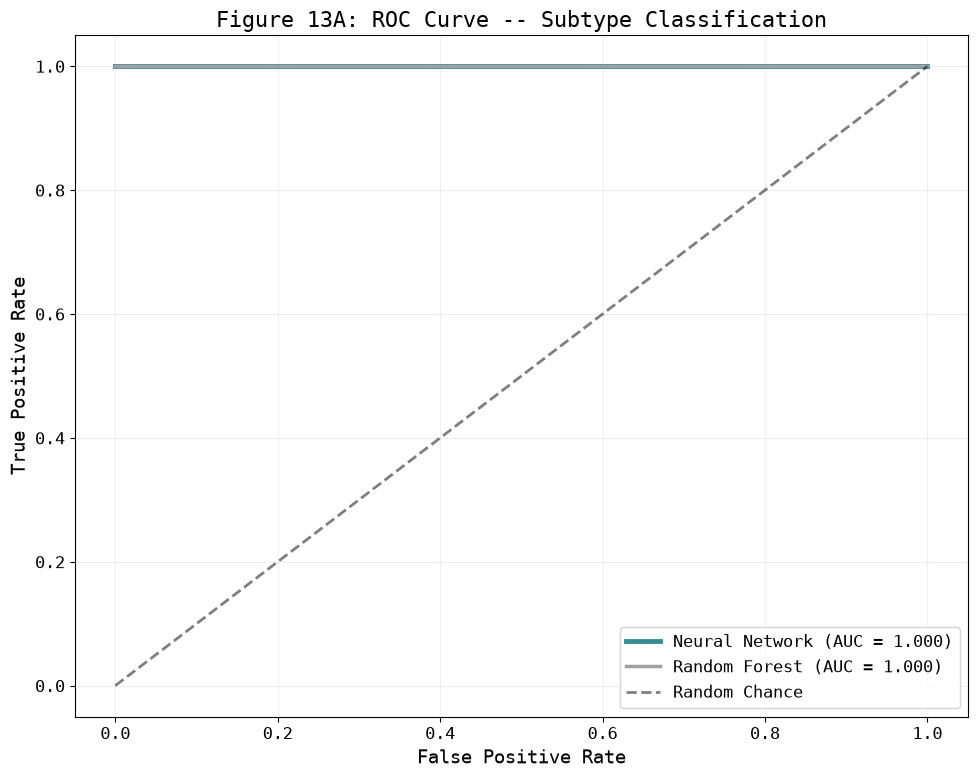

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
mean_fpr = np.linspace(0, 1, 100)
tprs_nn, tprs_rf = [], []

for fold in range(1, K_FOLDS+1):
    fold_mask = np.array(all_fold_indices) == fold
    y_fold = all_y_true[fold_mask]
    fpr_nn, tpr_nn, _ = roc_curve(y_fold, all_y_nn[fold_mask])
    tprs_nn.append(np.interp(mean_fpr, fpr_nn, tpr_nn))
    fpr_rf, tpr_rf_, _ = roc_curve(y_fold, all_y_rf[fold_mask])
    tprs_rf.append(np.interp(mean_fpr, fpr_rf, tpr_rf_))

for tprs, color, label, auc_val in [
    (tprs_nn, NN_COLOR, 'Neural Network', pooled_auc_nn),
    (tprs_rf, RF_COLOR, 'Random Forest', pooled_auc_rf)
]:
    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)
    lw = 3.5 if 'Neural' in label else 2.5
    ax.plot(mean_fpr, mean_tpr, color=color, lw=lw,
            label=f'{label} (AUC = {auc_val:.3f})')
    ax.fill_between(mean_fpr, np.maximum(mean_tpr - std_tpr, 0),
                     np.minimum(mean_tpr + std_tpr, 1), color=color, alpha=0.15)

ax.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5, label='Random Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Figure 13A: ROC Curve -- Subtype Classification')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure_13a_roc_curve.png"), dpi=300, bbox_inches='tight')
plt.show()

## 7. Precision-Recall Curve (Figure 13B)

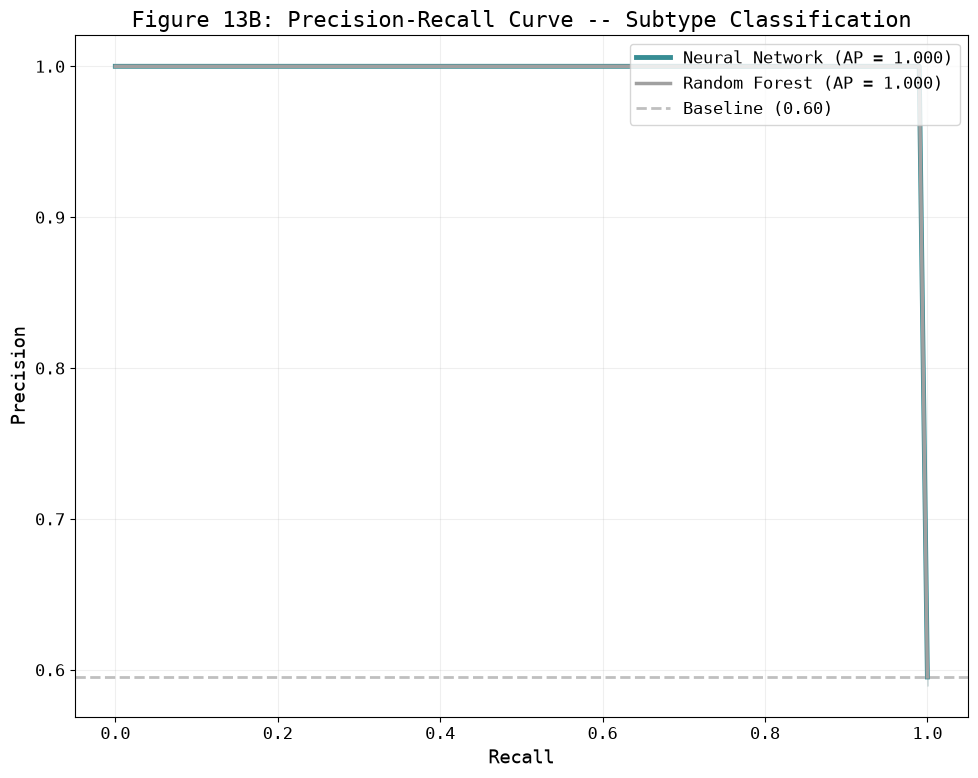

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
mean_recall = np.linspace(0, 1, 100)
precs_nn, precs_rf = [], []

for fold in range(1, K_FOLDS+1):
    fold_mask = np.array(all_fold_indices) == fold
    y_fold = all_y_true[fold_mask]
    prec_nn, rec_nn, _ = precision_recall_curve(y_fold, all_y_nn[fold_mask])
    precs_nn.append(np.interp(mean_recall, rec_nn[::-1], prec_nn[::-1]))
    prec_rf, rec_rf, _ = precision_recall_curve(y_fold, all_y_rf[fold_mask])
    precs_rf.append(np.interp(mean_recall, rec_rf[::-1], prec_rf[::-1]))

for precs, color, label, ap_val in [
    (precs_nn, NN_COLOR, 'Neural Network', pooled_ap_nn),
    (precs_rf, RF_COLOR, 'Random Forest', pooled_ap_rf)
]:
    mean_prec = np.mean(precs, axis=0)
    std_prec = np.std(precs, axis=0)
    lw = 3.5 if 'Neural' in label else 2.5
    ax.plot(mean_recall, mean_prec, color=color, lw=lw, label=f'{label} (AP = {ap_val:.3f})')
    ax.fill_between(mean_recall, np.maximum(mean_prec - std_prec, 0),
                     np.minimum(mean_prec + std_prec, 1), color=color, alpha=0.15)

ax.axhline(y=y.mean(), color='gray', linestyle='--', lw=2, alpha=0.5, label=f'Baseline ({y.mean():.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Figure 13B: Precision-Recall Curve -- Subtype Classification')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure_13b_pr_curve.png"), dpi=300, bbox_inches='tight')
plt.show()

## 8. Threshold Sweep (Figure 14)

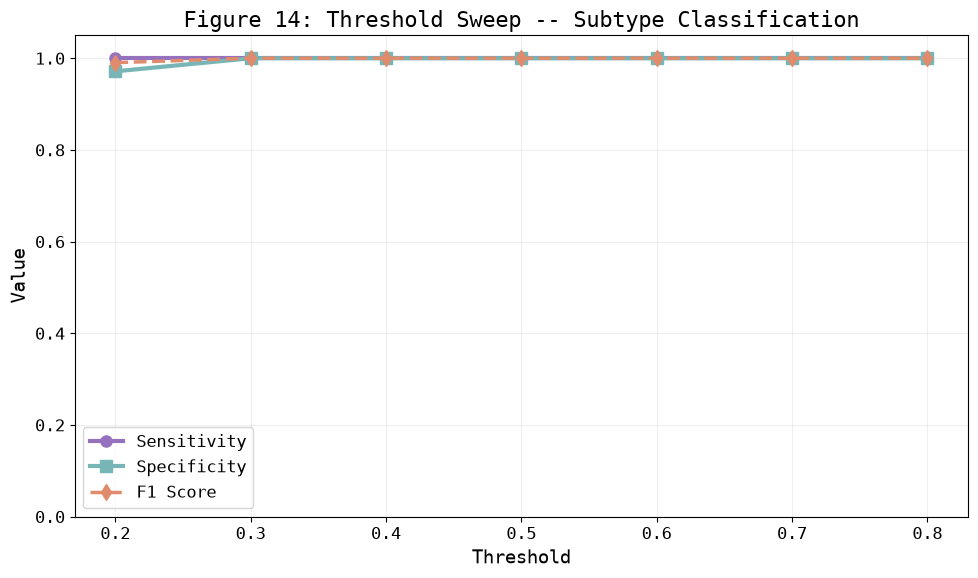

In [9]:
thresholds = np.arange(0.2, 0.9, 0.1)
sweep_rows = []
for t in thresholds:
    preds = (all_y_nn >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(all_y_true, preds).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0
    sweep_rows.append({'Threshold': t, 'Sensitivity': sens, 'Specificity': spec, 'PPV': ppv, 'F1': f1})

sweep_df = pd.DataFrame(sweep_rows)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sweep_df['Threshold'], sweep_df['Sensitivity'], 'o-', color=COLORS[0], lw=3, markersize=8, label='Sensitivity')
ax.plot(sweep_df['Threshold'], sweep_df['Specificity'], 's-', color=COLORS[1], lw=3, markersize=8, label='Specificity')
ax.plot(sweep_df['Threshold'], sweep_df['F1'], 'd--', color=COLORS[2], lw=2.5, markersize=8, label='F1 Score')
ax.set_xlabel('Threshold')
ax.set_ylabel('Value')
ax.set_title('Figure 14: Threshold Sweep -- Subtype Classification')
ax.legend()
ax.grid(True, alpha=0.2)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure_14_threshold_sweep.png"), dpi=300, bbox_inches='tight')
plt.show()

## 9. Confusion Matrices (Figure 15)

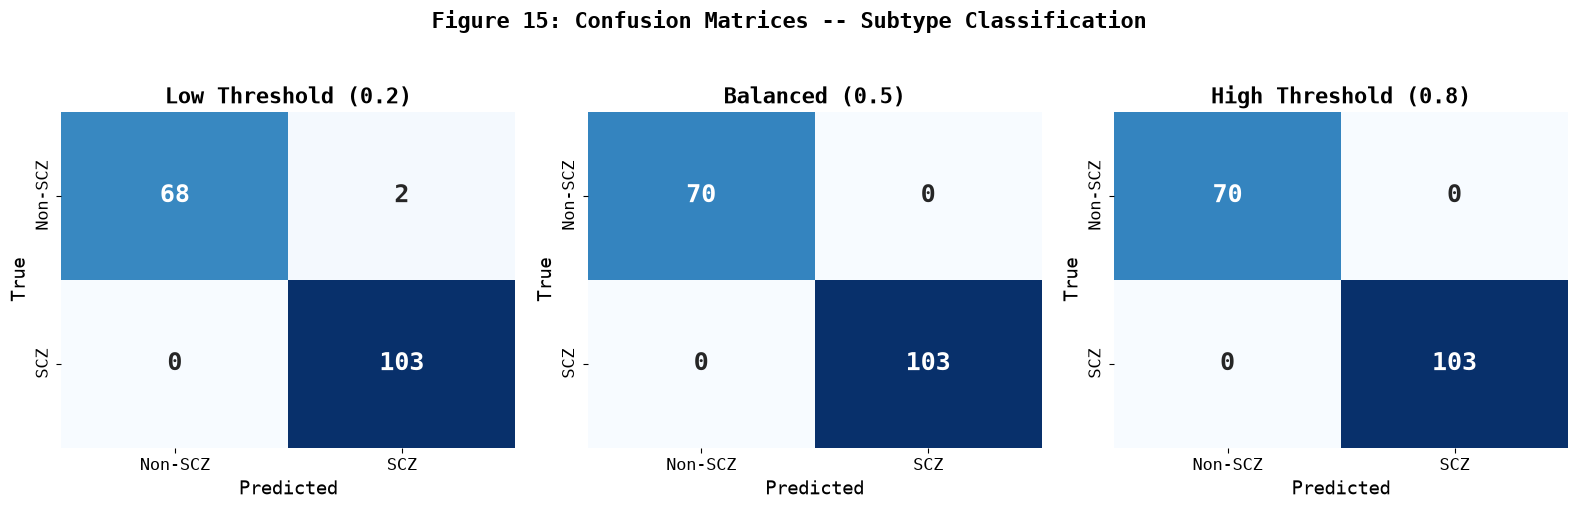

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, thresh, title in zip(axes, [0.2, 0.5, 0.8],
                              ['Low Threshold (0.2)', 'Balanced (0.5)', 'High Threshold (0.8)']):
    preds = (all_y_nn >= thresh).astype(int)
    cm = confusion_matrix(all_y_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                annot_kws={"size": 18, "weight": "bold"},
                xticklabels=['Non-SCZ', 'SCZ'], yticklabels=['Non-SCZ', 'SCZ'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.suptitle('Figure 15: Confusion Matrices -- Subtype Classification', fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure_15_confusion_matrices.png"), dpi=300, bbox_inches='tight')
plt.show()

## 10. Calibration Curve (Figure 16)

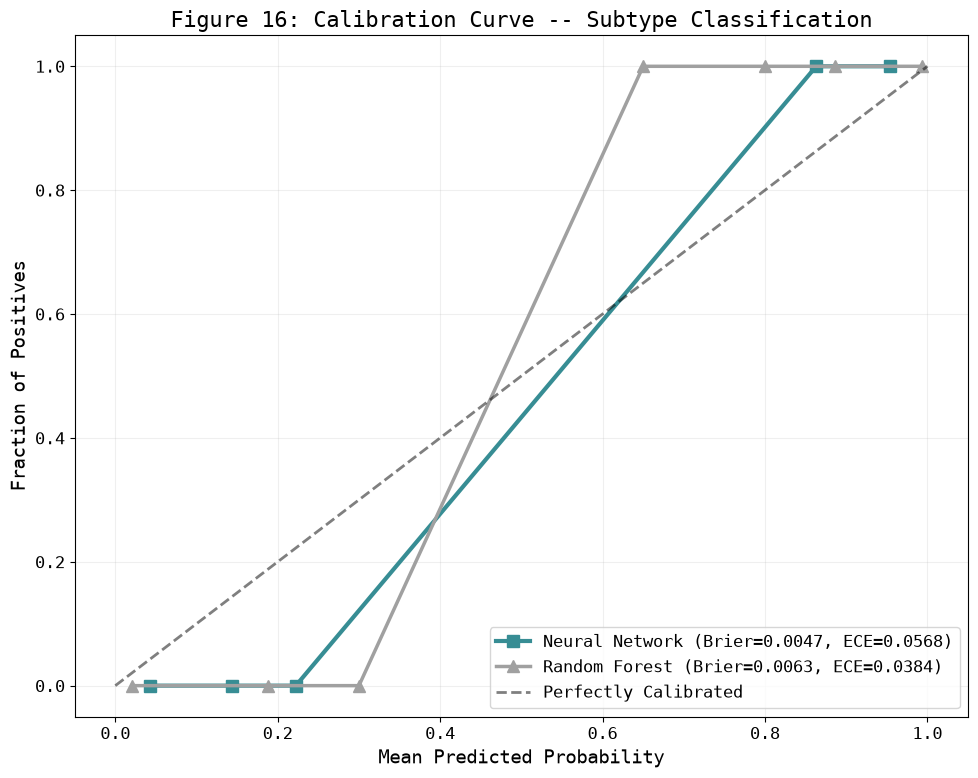


Calibration:
  NN -- Brier: 0.0047
  RF -- Brier: 0.0063

✓ Subtype classification complete.


In [11]:
def ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    cal = 0.0
    for i in range(n_bins):
        mask = binids == i
        if np.any(mask):
            cal += abs(np.mean(y_true[mask]) - np.mean(y_prob[mask])) * np.sum(mask) / len(y_true)
    return cal

prob_true_nn, prob_pred_nn = calibration_curve(all_y_true, all_y_nn, n_bins=10)
prob_true_rf, prob_pred_rf = calibration_curve(all_y_true, all_y_rf, n_bins=10)

brier_nn = brier_score_loss(all_y_true, all_y_nn)
brier_rf = brier_score_loss(all_y_true, all_y_rf)

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(prob_pred_nn, prob_true_nn, 's-', color=NN_COLOR, lw=3, markersize=8,
        label=f'Neural Network (Brier={brier_nn:.4f}, ECE={ece(all_y_true, all_y_nn):.4f})')
ax.plot(prob_pred_rf, prob_true_rf, '^-', color=RF_COLOR, lw=2.5, markersize=8,
        label=f'Random Forest (Brier={brier_rf:.4f}, ECE={ece(all_y_true, all_y_rf):.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5, label='Perfectly Calibrated')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Figure 16: Calibration Curve -- Subtype Classification')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure_16_calibration_curve.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nCalibration:")
print(f"  NN -- Brier: {brier_nn:.4f}")
print(f"  RF -- Brier: {brier_rf:.4f}")
print(f"\n✓ Subtype classification complete.")